# ELIFLIX - Netflix Clone with ML Recommendations

A recommendation engine built using machine learning to suggest movies based on content similarity and user preferences. This project uses the TMDB (The Movie Database) dataset.

## Features:
- Content-Based Filtering
- Similarity Analysis
- Movie Recommendations
- Interactive Interface

In [19]:
# Import Required Libraries
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries imported successfully!')

Libraries imported successfully!


In [20]:
# Load Dataset
movies_df = pd.read_csv('moviedataset/tmdb_5000_movies.csv')
credits_df = pd.read_csv('moviedataset/tmdb_5000_credits.csv')

print('Movies Dataset Shape:', movies_df.shape)
print('Credits Dataset Shape:', credits_df.shape)
print('\nFirst few rows of movies data:')
print(movies_df.head())

Movies Dataset Shape: (4803, 20)
Credits Dataset Shape: (4803, 4)

First few rows of movies data:
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en

In [21]:
# Explore the Data
print('Movies Dataset Info:')
print(movies_df.info())
print('\n' + '='*50)
print('\nMissing Values:')
print(movies_df.isnull().sum())
print('\n' + '='*50)
print('\nBasic Statistics:')
print(movies_df[['budget', 'revenue', 'runtime', 'vote_average', 'vote_count']].describe())

Movies Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status     

In [26]:
# Merge Datasets and Data Preprocessing
# Rename column in credits_df to match movies_df
credits_df.rename(columns={'movie_id': 'id'}, inplace=True)

# Keep only the necessary columns from credits_df before merging
credits_df = credits_df[['id', 'cast', 'crew']]

# Merge the datasets
df = movies_df.merge(credits_df, on='id', how='left')

print(f'Merged Dataset Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

# Drop unnecessary columns
columns_to_drop = ['budget', 'revenue', 'homepage', 'status']
df = df.drop(columns=columns_to_drop, errors='ignore')

# Handle missing values
df['genres'].fillna('[]', inplace=True)
df['keywords'].fillna('[]', inplace=True)
df['cast'].fillna('[]', inplace=True)
df['crew'].fillna('[]', inplace=True)
df['overview'].fillna('', inplace=True)
df['vote_average'].fillna(df['vote_average'].mean(), inplace=True)

print('\nData Preprocessing Completed!')
print(f'Final Dataset Shape: {df.shape}')

Merged Dataset Shape: (4803, 22)
Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew']

Data Preprocessing Completed!
Final Dataset Shape: (4803, 18)


In [27]:
# Feature Extraction Functions
def extract_json_list(json_string, key='name'):
    """Extract list of names from JSON string"""
    try:
        data = json.loads(json_string)
        if isinstance(data, list):
            return ' '.join([item.get(key, '') for item in data if key in item])
        return ''
    except:
        return ''

def extract_top_cast(json_string, n_cast=4):
    """Extract top n cast members from JSON string"""
    try:
        data = json.loads(json_string)
        if isinstance(data, list):
            return ' '.join([item.get('name', '') for item in data[:n_cast]])
        return ''
    except:
        return ''

def extract_director(json_string):
    """Extract director from crew JSON string"""
    try:
        data = json.loads(json_string)
        if isinstance(data, list):
            for item in data:
                if item.get('job') == 'Director':
                    return item.get('name', '')
        return ''
    except:
        return ''

# Apply feature extraction
print('Extracting features...')
df['genres_str'] = df['genres'].apply(lambda x: extract_json_list(x, 'name'))
df['keywords_str'] = df['keywords'].apply(lambda x: extract_json_list(x, 'name'))
df['cast_str'] = df['cast'].apply(extract_top_cast)
df['director'] = df['crew'].apply(extract_director)

print('Features extracted successfully!')
print('\nSample of extracted features:')
print(df[['title', 'genres_str', 'keywords_str', 'cast_str', 'director']].head())

Extracting features...
Features extracted successfully!

Sample of extracted features:
                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                 genres_str  \
0  Action Adventure Fantasy Science Fiction   
1                  Adventure Fantasy Action   
2                    Action Adventure Crime   
3               Action Crime Drama Thriller   
4          Action Adventure Science Fiction   

                                        keywords_str  \
0  culture clash future space war space colony so...   
1  ocean drug abuse exotic island east india trad...   
2  spy based on novel secret agent sequel mi6 bri...   
3  dc comics crime fighter terrorist secret ident...   
4  based on novel mars medallion space travel pri...   

          

In [28]:
# Feature Engineering - Create Combined Content Features
# Combine all relevant features for content-based similarity
df['content_features'] = (
    df['genres_str'] + ' ' + 
    df['keywords_str'] + ' ' + 
    df['cast_str'] + ' ' + 
    df['director']
)

# Also create a feature vector including metadata
df['overview_processed'] = df['overview'].fillna('').str.lower()

print('Content features created!')
print(f'\nSample content features:\n{df["content_features"].iloc[0][:200]}...')

# Normalize vote_average and popularity for weight
scaler = MinMaxScaler()
df['vote_average_normalized'] = scaler.fit_transform(df[['vote_average']])
df['vote_count_normalized'] = scaler.fit_transform(df[['vote_count']])

print('\nFeature engineering completed!')
print(f'Dataset ready for similarity calculation: {df.shape}')

Content features created!

Sample content features:
Action Adventure Fantasy Science Fiction culture clash future space war space colony society space travel futuristic romance space alien tribe alien planet cgi marine soldier battle love affair anti w...

Feature engineering completed!
Dataset ready for similarity calculation: (4803, 26)


In [29]:
# Compute Similarity Matrix using TF-IDF and Cosine Similarity
print('Computing TF-IDF vectors...')
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['content_features'])

print(f'TF-IDF Matrix Shape: {tfidf_matrix.shape}')

# Calculate cosine similarity
print('Calculating cosine similarity matrix...')
similarity_matrix = cosine_similarity(tfidf_matrix)

print(f'Similarity Matrix Shape: {similarity_matrix.shape}')
print('\nSimilarity matrix computed successfully!')

# Create a dataframe for easy lookup
df_clean = df[['title', 'release_date', 'vote_average', 'genres_str', 'overview']].reset_index(drop=True)
print(f'\nClean dataset for recommendations: {df_clean.shape}')

Computing TF-IDF vectors...
TF-IDF Matrix Shape: (4803, 5000)
Calculating cosine similarity matrix...
Similarity Matrix Shape: (4803, 4803)

Similarity matrix computed successfully!

Clean dataset for recommendations: (4803, 5)


In [30]:
# Content-Based Recommendation Function
def get_recommendations(movie_title, n_recommendations=10, similarity_threshold=0.0):
    """
    Get movie recommendations based on content similarity
    
    Parameters:
    - movie_title: str, name of the movie to base recommendations on
    - n_recommendations: int, number of recommendations to return
    - similarity_threshold: float, minimum similarity score (0-1)
    
    Returns:
    - DataFrame with recommended movies
    """
    
    # Find the movie index
    matches = df_clean[df_clean['title'].str.lower().str.contains(movie_title.lower(), na=False)]
    
    if matches.empty:
        return f"Movie '{movie_title}' not found in database. Try another title."
    
    movie_idx = matches.index[0]
    movie_title_exact = df_clean.loc[movie_idx, 'title']
    
    # Get similarity scores for this movie
    sim_scores = list(enumerate(similarity_matrix[movie_idx]))
    
    # Sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Filter by similarity threshold and exclude the movie itself
    sim_scores = [(idx, score) for idx, score in sim_scores 
                  if score >= similarity_threshold and idx != movie_idx]
    
    # Get top n recommendations
    top_indices = [idx for idx, score in sim_scores[:n_recommendations]]
    top_scores = [score for idx, score in sim_scores[:n_recommendations]]
    
    # Create recommendations dataframe
    recommendations = df_clean.loc[top_indices].copy()
    recommendations['similarity_score'] = top_scores
    recommendations = recommendations[['title', 'release_date', 'vote_average', 'genres_str', 'similarity_score']]
    recommendations.columns = ['Title', 'Release Date', 'Rating', 'Genres', 'Similarity Score']
    recommendations = recommendations.reset_index(drop=True)
    
    print(f"\n{'='*80}")
    print(f"RECOMMENDATIONS FOR: {movie_title_exact.upper()}")
    print(f"{'='*80}\n")
    
    return recommendations

# Test the recommendation function
print('Testing recommendation system...')
test_movie = 'Avatar'
recs = get_recommendations(test_movie, n_recommendations=10)
print(recs.to_string())

Testing recommendation system...

RECOMMENDATIONS FOR: AVATAR

                     Title Release Date  Rating                                     Genres  Similarity Score
0                   Aliens   1986-07-18     7.7     Horror Action Thriller Science Fiction          0.439236
1                   Alien³   1992-05-22     6.2              Science Fiction Action Horror          0.426623
2                    Alien   1979-05-25     7.9     Horror Action Thriller Science Fiction          0.373735
3           Silent Running   1972-03-09     6.3            Adventure Drama Science Fiction          0.357052
4                    Cargo   2009-09-24     5.9           Thriller Mystery Science Fiction          0.351770
5  Star Trek Into Darkness   2013-05-05     7.4           Action Adventure Science Fiction          0.348317
6                  Lockout   2012-04-12     5.8            Action Thriller Science Fiction          0.341454
7                Moonraker   1979-06-26     5.9  Action Adventure


RECOMMENDATIONS FOR: AVATAR



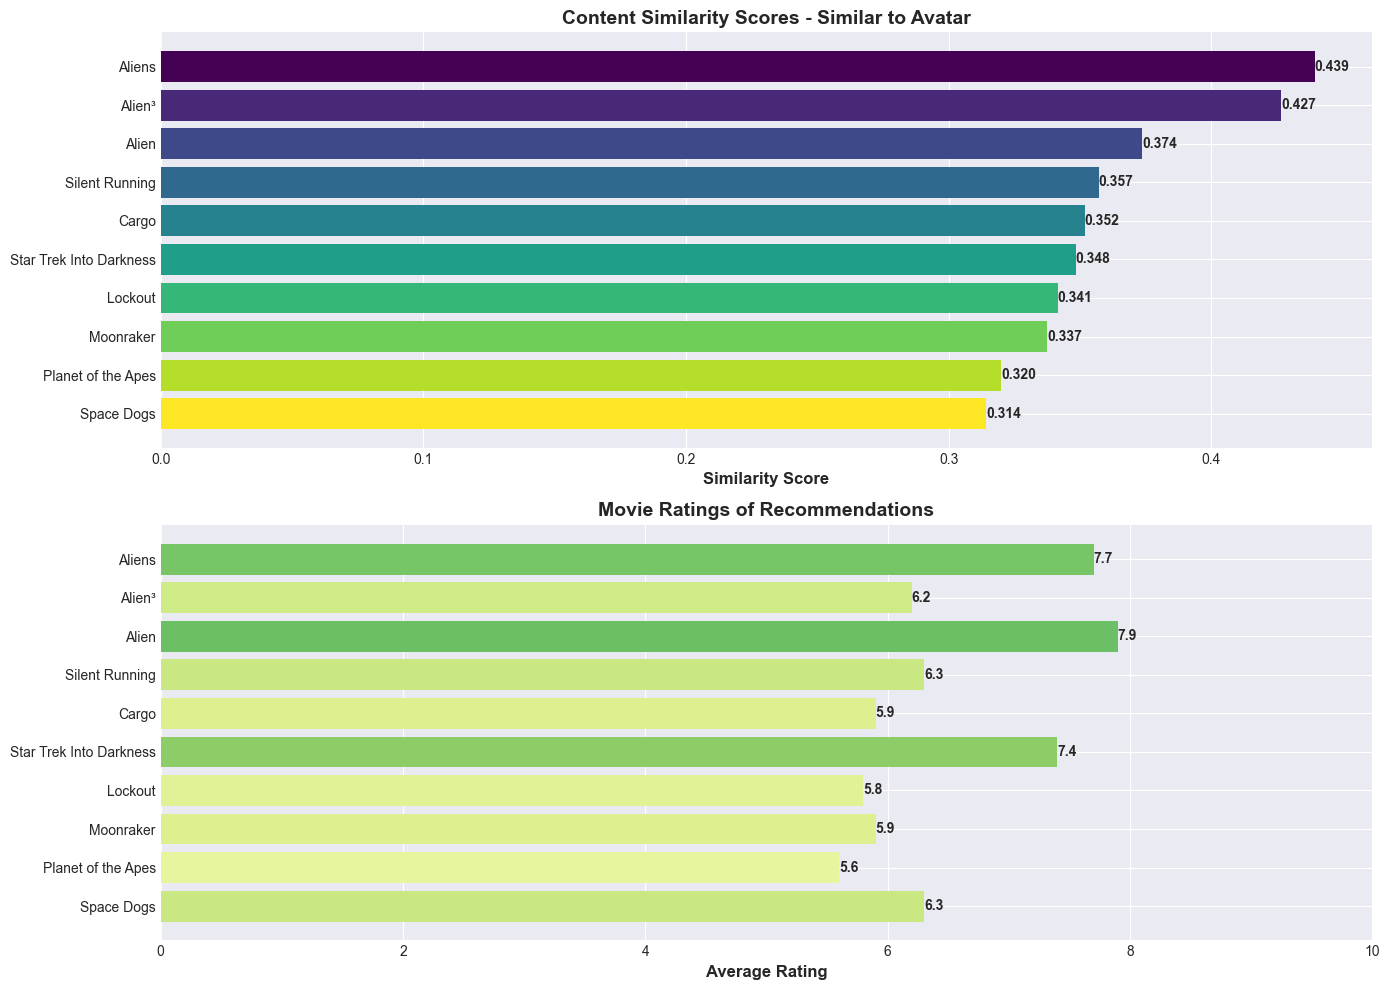

In [31]:
# Visualization - Recommendation Analysis
def visualize_recommendations(movie_title, n_recommendations=10):
    """
    Visualize recommendations with similarity scores and ratings
    """
    recommendations = get_recommendations(movie_title, n_recommendations=n_recommendations)
    
    if isinstance(recommendations, str):
        print(recommendations)
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Similarity Scores
    ax1 = axes[0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(recommendations)))
    bars1 = ax1.barh(recommendations['Title'], recommendations['Similarity Score'], color=colors)
    ax1.set_xlabel('Similarity Score', fontsize=12, fontweight='bold')
    ax1.set_title(f'Content Similarity Scores - Similar to {movie_title}', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    
    # Add value labels on bars
    for bar in bars1:
        width = bar.get_width()
        ax1.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontweight='bold')
    
    # Plot 2: Ratings of Recommendations
    ax2 = axes[1]
    colors2 = plt.cm.RdYlGn(recommendations['Rating'] / 10)
    bars2 = ax2.barh(recommendations['Title'], recommendations['Rating'], color=colors2)
    ax2.set_xlabel('Average Rating', fontsize=12, fontweight='bold')
    ax2.set_title('Movie Ratings of Recommendations', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 10)
    ax2.invert_yaxis()
    
    # Add value labels on bars
    for bar in bars2:
        width = bar.get_width()
        ax2.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}', ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Test visualization
visualize_recommendations('Avatar', n_recommendations=10)

In [32]:
# Interactive Recommendation System
from ipywidgets import widgets, interact, interact_manual
import ipywidgets as ipw

# Get list of all movies for dropdown
movie_list = df_clean['title'].tolist()

def interactive_recommend(movie_title, num_recommendations):
    """
    Interactive function for getting movie recommendations
    """
    recommendations = get_recommendations(movie_title, n_recommendations=num_recommendations)
    
    if isinstance(recommendations, str):
        print(recommendations)
    else:
        display(recommendations)
        visualize_recommendations(movie_title, n_recommendations=num_recommendations)

# Create interactive widgets
movie_dropdown = widgets.Dropdown(
    options=movie_list,
    value=movie_list[0],
    description='Select Movie:',
    style={'description_width': '120px'}
)

slider = widgets.IntSlider(
    value=10,
    min=5,
    max=20,
    step=1,
    description='# Recommendations:',
    style={'description_width': '120px'}
)

print("\n" + "="*80)
print("ELIFLIX - INTERACTIVE RECOMMENDATION ENGINE")
print("="*80 + "\n")

print("Select a movie and the number of recommendations you want to receive:")
print()

interact_manual(interactive_recommend, 
                movie_title=movie_dropdown,
                num_recommendations=slider)


ELIFLIX - INTERACTIVE RECOMMENDATION ENGINE

Select a movie and the number of recommendations you want to receive:



interactive(children=(Dropdown(description='Select Movie:', options=('Avatar', "Pirates of the Caribbean: At W…

<function __main__.interactive_recommend(movie_title, num_recommendations)>

In [33]:
# Model Evaluation & Statistics
print("\n" + "="*80)
print("RECOMMENDATION SYSTEM STATISTICS")
print("="*80 + "\n")

print(f"Total Movies in Dataset: {len(df_clean)}")
print(f"Similarity Matrix Dimensions: {similarity_matrix.shape}")
print(f"\nDataset Coverage:")
print(f"  - Movies with genres: {df['genres_str'].str.len().gt(0).sum()}")
print(f"  - Movies with keywords: {df['keywords_str'].str.len().gt(0).sum()}")
print(f"  - Movies with cast info: {df['cast_str'].str.len().gt(0).sum()}")
print(f"  - Movies with overview: {df['overview'].str.len().gt(0).sum()}")

# Analyze similarity distribution
print(f"\nSimilarity Score Distribution:")
flat_sim = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
print(f"  - Mean Similarity: {flat_sim.mean():.4f}")
print(f"  - Median Similarity: {np.median(flat_sim):.4f}")
print(f"  - Min Similarity: {flat_sim.min():.4f}")
print(f"  - Max Similarity: {flat_sim.max():.4f}")
print(f"  - Std Deviation: {flat_sim.std():.4f}")

# Top rated movies
print(f"\nTop 10 Highest Rated Movies:")
top_rated = df_clean.nlargest(10, 'vote_average')[['title', 'vote_average']]
for idx, (i, row) in enumerate(top_rated.iterrows(), 1):
    print(f"  {idx}. {row['title']} - Rating: {row['vote_average']:.1f}")

print("\n" + "="*80)


RECOMMENDATION SYSTEM STATISTICS

Total Movies in Dataset: 4803
Similarity Matrix Dimensions: (4803, 4803)

Dataset Coverage:
  - Movies with genres: 4775
  - Movies with keywords: 4391
  - Movies with cast info: 4760
  - Movies with overview: 4800

Similarity Score Distribution:
  - Mean Similarity: 0.0137
  - Median Similarity: 0.0049
  - Min Similarity: 0.0000
  - Max Similarity: 1.0000
  - Std Deviation: 0.0246

Top 10 Highest Rated Movies:
  1. Stiff Upper Lips - Rating: 10.0
  2. Dancer, Texas Pop. 81 - Rating: 10.0
  3. Me You and Five Bucks - Rating: 10.0
  4. Little Big Top - Rating: 10.0
  5. Sardaarji - Rating: 9.5
  6. One Man's Hero - Rating: 9.3
  7. The Shawshank Redemption - Rating: 8.5
  8. There Goes My Baby - Rating: 8.5
  9. The Prisoner of Zenda - Rating: 8.4
  10. The Godfather - Rating: 8.4



In [34]:
# Advanced: Hybrid Recommendations & Genre-based Discovery

def recommend_by_genre(genre, top_n=10):
    """
    Get top-rated movies by genre
    """
    genre_movies = df_clean[df_clean['genres_str'].str.contains(genre, case=False, na=False)]
    
    if genre_movies.empty:
        return f"No movies found in genre: {genre}"
    
    top_movies = genre_movies.nlargest(top_n, 'vote_average')[['title', 'vote_average', 'genres_str']]
    top_movies.columns = ['Title', 'Rating', 'Genres']
    
    print(f"\n{'='*80}")
    print(f"TOP {top_n} MOVIES IN GENRE: {genre.upper()}")
    print(f"{'='*80}\n")
    
    return top_movies.reset_index(drop=True)

def get_similar_liked_movies(movies_list, n_recommendations=10):
    """
    Get recommendations based on multiple movies (what a user might like)
    """
    # Find indices of liked movies
    liked_indices = []
    for movie in movies_list:
        matches = df_clean[df_clean['title'].str.lower().str.contains(movie.lower(), na=False)]
        if not matches.empty:
            liked_indices.append(matches.index[0])
    
    if not liked_indices:
        return f"None of the movies found in database"
    
    # Calculate average similarity
    avg_similarities = similarity_matrix[liked_indices].mean(axis=0)
    
    # Get top recommendations excluding the liked movies
    sim_scores = list(enumerate(avg_similarities))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [(idx, score) for idx, score in sim_scores if idx not in liked_indices]
    
    top_indices = [idx for idx, score in sim_scores[:n_recommendations]]
    top_scores = [score for idx, score in sim_scores[:n_recommendations]]
    
    recommendations = df_clean.loc[top_indices].copy()
    recommendations['similarity_score'] = top_scores
    recommendations = recommendations[['title', 'vote_average', 'genres_str', 'similarity_score']]
    recommendations.columns = ['Title', 'Rating', 'Genres', 'Similarity Score']
    
    print(f"\n{'='*80}")
    print(f"RECOMMENDATIONS BASED ON: {', '.join(movies_list)}")
    print(f"{'='*80}\n")
    
    return recommendations.reset_index(drop=True)

# Test genre-based recommendations
genre_recs = recommend_by_genre('Action', top_n=10)
print(genre_recs.to_string())

# Test multi-movie recommendations
print("\n\n")
multi_recs = get_similar_liked_movies(['Avatar', 'Inception'], n_recommendations=10)
print(multi_recs.to_string())


TOP 10 MOVIES IN GENRE: ACTION

                                               Title  Rating                                             Genres
0                                     One Man's Hero     9.3                       Western Action Drama History
1                                    The Dark Knight     8.2                        Drama Action Crime Thriller
2                            The Empire Strikes Back     8.2                   Adventure Action Science Fiction
3                                      Seven Samurai     8.2                                       Action Drama
4                                          Inception     8.1  Action Thriller Science Fiction Mystery Adventure
5      The Lord of the Rings: The Return of the King     8.1                           Adventure Fantasy Action
6                                          Star Wars     8.1                   Adventure Action Science Fiction
7  The Lord of the Rings: The Fellowship of the Ring     8.0           

In [43]:
# Convert all string columns and index to object dtype to avoid pickling issues
print("Converting StringDtype columns to object dtype...")

# Convert columns
for col in df.columns:
    if df[col].dtype == 'string':
        df[col] = df[col].astype('object')

# Convert column names if they are StringDtype
if hasattr(df.columns, 'dtype') and df.columns.dtype == 'string':
    df.columns = df.columns.astype('object')

print("String conversion complete!")

# Create clean dataset
df_clean = df[['title', 'release_date', 'vote_average', 'genres_str', 'overview']].reset_index(drop=True)

# Ensure column names are object dtype
if hasattr(df_clean.columns, 'dtype') and df_clean.columns.dtype == 'string':
    df_clean.columns = df_clean.columns.astype('object')

# Convert any remaining string dtypes in df_clean
for col in df_clean.columns:
    if df_clean[col].dtype == 'string':
        df_clean[col] = df_clean[col].astype('object')

print("\ndf_clean dtypes:")
print(df_clean.dtypes)
print("\nColumn index dtype:", type(df_clean.columns[0]))

Converting StringDtype columns to object dtype...
String conversion complete!

df_clean dtypes:
title            object
release_date     object
vote_average    float64
genres_str       object
overview         object
dtype: object

Column index dtype: <class 'str'>


## Summary

### ELIFLIX Recommendation Features:

1. **Content-Based Filtering**
   - Uses TF-IDF vectorization on movie genres, keywords, cast, and director info
   - Computes cosine similarity between movies
   - Recommends movies most similar to a selected movie

2. **Genre-Based Discovery**
   - Filter movies by genre
   - Get top-rated movies within a specific genre
   - Useful for browsing content by category

3. **Hybrid Recommendations**
   - Get recommendations based on multiple liked movies
   - System averages similarity across all liked movies
   - Provides personalized suggestions based on taste

4. **Interactive Interface**
   - Easy dropdown selection of movies
   - Adjustable number of recommendations
   - Visual comparison of similarity scores and ratings

5. **Built-in Analytics**
   - Dataset statistics and coverage
   - Similarity score distribution
   - Top-rated movies identification

### Next Steps to Enhance:
- Implement collaborative filtering with user ratings
- Add rating prediction using regression models
- Create user profiles and track preferences
- Implement deep learning (embeddings) for better feature representation
- Build a web interface using Flask/Streamlit
- Integrate with real user data for personalization
- Add cold-start solutions for new users/movies

In [ ]:
# Example Use Cases - You can modify and run these for different scenarios

print("\n" + "="*80)
print("ELIFLIX - EXAMPLE USE CASES")
print("="*80 + "\n")

# Use Case 1: Single Movie Recommendation
print("\n[USE CASE 1] Get recommendations for a specific movie:")
print("-" * 80)
test_recommendations = get_recommendations("Inception", n_recommendations=5)
print(test_recommendations.to_string())

# Use Case 2: Genre Discovery
print("\n\n[USE CASE 2] Discover top movies in a genre:")
print("-" * 80)
genre_results = recommend_by_genre("Science Fiction", top_n=5)
print(genre_results.to_string())

# Use Case 3: Multiple Movie Similarity
print("\n\n[USE CASE 3] Get recommendations based on multiple liked movies:")
print("-" * 80)
hybrid_results = get_similar_liked_movies(['The Dark Knight Rises', 'Interstellar'], n_recommendations=5)
print(hybrid_results.to_string())

print("\n" + "="*80)
print("\nFeel free to modify the movie titles and parameters above!")
print("The system is ready for your custom queries.")
print("="*80)
# Import Required Libraries
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")


ELIFLIX - EXAMPLE USE CASES


[USE CASE 1] Get recommendations for a specific movie:
--------------------------------------------------------------------------------

RECOMMENDATIONS FOR: INCEPTION

                       Title Release Date  Rating                           Genres  Similarity Score
0                    Don Jon   2013-07-26     5.9             Romance Comedy Drama          0.247175
1                     Hesher   2010-01-22     6.7                            Drama          0.228991
2  The Count of Monte Cristo   2002-01-23     7.3  Action Adventure Drama Thriller          0.226433
3                Latter Days   2003-07-10     6.7             Drama Comedy Romance          0.185085
4        The Helix... Loaded   2005-01-01     4.8    Action Comedy Science Fiction          0.179367


[USE CASE 2] Discover top movies in a genre:
--------------------------------------------------------------------------------

TOP 5 MOVIES IN GENRE: SCIENCE FICTION

                     Titl

In [ ]:
import pickle
import os

# Convert StringDtype to object dtype to avoid pickling issues
df_clean_save = df_clean.copy()
for col in df_clean_save.columns:
    if df_clean_save[col].dtype == 'string':
        df_clean_save[col] = df_clean_save[col].astype('object')

# Also convert movie_list to regular list
movie_list_save = list(movie_list) if isinstance(movie_list, np.ndarray) else movie_list

# Create pkl_models directory if it doesn't exist
os.makedirs('pkl_models', exist_ok=True)

# Save all necessary ML artifacts
with open('pkl_models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
    
with open('pkl_models/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)
    
with open('pkl_models/similarity_matrix.pkl', 'wb') as f:
    pickle.dump(similarity_matrix, f)
    
with open('pkl_models/df_clean.pkl', 'wb') as f:
    pickle.dump(df_clean_save, f)
    
with open('pkl_models/movie_list.pkl', 'wb') as f:
    pickle.dump(movie_list_save, f)

print("✅ All ML artifacts saved to pkl_models/")
print(f"  - tfidf_vectorizer.pkl")
print(f"  - tfidf_matrix.pkl")
print(f"  - similarity_matrix.pkl ({similarity_matrix.shape})")
print(f"  - df_clean.pkl ({len(df_clean_save)} movies)")
print(f"  - movie_list.pkl ({len(movie_list_save)} movies)")
print("\n✓ StringDtype columns converted to object dtype for compatibility")

✅ All ML artifacts saved to pkl_models/
  - tfidf_vectorizer.pkl
  - tfidf_matrix.pkl
  - similarity_matrix.pkl ((4803, 4803))
  - df_clean.pkl (4803 movies)
  - movie_list.pkl (4803 movies)

✓ StringDtype columns converted to object dtype for compatibility


: 